In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('dataset.csv')

In [6]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import xgboost as xgb
import lightgbm as lgb

In [9]:
df['closed_datetime']   = pd.to_datetime(df['closed_datetime'],   utc=True, errors='coerce')
df['start_datetime']    = pd.to_datetime(df['start_datetime'],     utc=True, errors='coerce')
df['resolved_datetime'] = pd.to_datetime(df['resolved_datetime'],  utc=True, errors='coerce')

df['end_ts']        = df['closed_datetime'].fillna(df['resolved_datetime'])
df['duration_mins'] = (df['end_ts'] - df['start_datetime']).dt.total_seconds() / 60

df['severity'] = pd.cut(
    df['duration_mins'],
    bins=[0, 30, 90, 240, 1440],
    labels=['low', 'medium', 'high', 'critical'],
    include_lowest=True
)
severity_map = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
df['severity_enc'] = df['severity'].map(severity_map)


mask = (
    df['duration_mins'].notna() &
    df['severity_enc'].notna() &
    (df['duration_mins'] > 0) &
    (df['duration_mins'] < 1440) &
    df['priority'].notna() &
    df['address'].notna()
)
df_clean = df[mask].copy()
print(f"Rows after all filters: {len(df_clean)}")

CAT_FILL = ['zone', 'junction', 'gba_identifier', 'veh_type', 'corridor']
for col in CAT_FILL:
    df_clean[col] = df_clean[col].fillna('Unknown')

df_clean['requires_road_closure'] = df_clean['requires_road_closure'].astype(int)

df_clean['hour']        = df_clean['start_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['start_datetime'].dt.dayofweek
df_clean['month']       = df_clean['start_datetime'].dt.month
df_clean['is_weekend']  = df_clean['day_of_week'].isin([5, 6]).astype(int)
df_clean['is_peak']     = df_clean['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df_clean['is_night']    = df_clean['hour'].isin(list(range(22, 24)) + [0, 1, 2]).astype(int)

df_clean['lat_bin']          = pd.cut(df_clean['latitude'],  bins=8, labels=False)
df_clean['lon_bin']          = pd.cut(df_clean['longitude'], bins=8, labels=False)
df_clean['has_end_location'] = (df_clean['endlatitude'].fillna(0) != 0).astype(int)


LE_COLS = ['event_type', 'event_cause', 'veh_type', 'status']
le_encoders = {}
for col in LE_COLS:
    le = LabelEncoder()
    df_clean[f'{col}_enc'] = le.fit_transform(df_clean[col].astype(str))
    le_encoders[col] = le

# priority ordinal
priority_map = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
df_clean['priority_enc'] = df_clean['priority'].str.lower().map(priority_map).fillna(1).astype(int)


for col in ['zone', 'junction', 'corridor', 'gba_identifier']:
    mean_map = df_clean.groupby(col)['duration_mins'].mean()
    df_clean[f'{col}_tenc']  = df_clean[col].map(mean_map).fillna(df_clean['duration_mins'].mean())
    df_clean[f'{col}_known'] = (df_clean[col] != 'Unknown').astype(int)


FEATURE_COLS = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak', 'is_night',
    'latitude', 'longitude', 'lat_bin', 'lon_bin', 'has_end_location',
    'event_type_enc', 'event_cause_enc',
    'veh_type_enc', 'status_enc',
    'zone_tenc',    'zone_known',
    'junction_tenc', 'junction_known',
    'corridor_tenc', 'corridor_known',
    'gba_identifier_tenc', 'gba_identifier_known',
    'priority_enc',
]

# Verify every column actually exists
missing_feats = [c for c in FEATURE_COLS if c not in df_clean.columns]
if missing_feats:
    print(f"STILL MISSING: {missing_feats}")
else:
    print("All feature columns present")


X       = df_clean[FEATURE_COLS].fillna(-999)
y_reg   = df_clean['duration_mins']
y_clf_b = df_clean['requires_road_closure']
y_clf_m = df_clean['severity_enc'].astype(int)

# Single stratified split — same indices for all three tasks
X_train, X_test, \
y_reg_train, y_reg_test, \
y_b_train, y_b_test, \
y_m_train, y_m_test = train_test_split(
    X, y_reg, y_clf_b, y_clf_m,
    test_size=0.2, random_state=42
)

print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"NaN in y_reg_train : {y_reg_train.isna().sum()}")
print(f"NaN in y_b_train   : {y_b_train.isna().sum()}")
print(f"NaN in y_m_train   : {y_m_train.isna().sum()}")
print(f"Classes in y_m     : {sorted(y_clf_m.unique())}")
print(f"has_end_location corr with road_closure: "
      f"{X['has_end_location'].corr(y_clf_b):.4f}")

Rows after all filters: 2523
All feature columns present

Train size: 2018  |  Test size: 505
NaN in y_reg_train : 0
NaN in y_b_train   : 0
NaN in y_m_train   : 0
Classes in y_m     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
has_end_location corr with road_closure: 0.9887


In [11]:
FEATURE_COLS_B = [
    c for c in FEATURE_COLS
    if c not in ('requires_road_closure', 'has_end_location')
]


FEATURE_COLS_A = FEATURE_COLS          # all features for regression
FEATURE_COLS_C = [c for c in FEATURE_COLS if c != 'priority_enc']  # no leakage into severity

X_tr_b, X_te_b = X_train[FEATURE_COLS_B], X_test[FEATURE_COLS_B]
X_tr_a, X_te_a = X_train[FEATURE_COLS_A], X_test[FEATURE_COLS_A]
X_tr_c, X_te_c = X_train[FEATURE_COLS_C], X_test[FEATURE_COLS_C]

print(f"Features — A:{len(FEATURE_COLS_A)}  B:{len(FEATURE_COLS_B)}  C:{len(FEATURE_COLS_C)}")

Features — A:24  B:23  C:23


In [13]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

def regression_report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  MAE : {mae:.2f} mins")
    print(f"  RMSE: {rmse:.2f} mins")
    print(f"  R²  : {r2:.4f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

def classification_report_short(name, y_true, y_pred, y_prob=None, multi=False):
    f1 = f1_score(y_true, y_pred, average='weighted')
    auc = None
    if y_prob is not None:
        if multi:
            auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
        else:
            auc = roc_auc_score(y_true, y_prob)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  F1 (weighted): {f1:.4f}")
    if auc is not None:
        print(f"  ROC-AUC:       {auc:.4f}")
    return {'model': name, 'F1': f1, 'AUC': auc}

In [14]:
print("\n" + "="*50)
print("  TASK A: DURATION REGRESSION")
print("="*50)

results_reg = []

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_reg_train)
pred = ridge_pipe.predict(X_test)
results_reg.append(regression_report("Ridge (baseline)", y_reg_test, pred))

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
pred = rf_reg.predict(X_test)
results_reg.append(regression_report("RandomForest", y_reg_test, pred))

xgb_reg = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='mae',
    early_stopping_rounds=30, verbosity=0
)
xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    verbose=False
)
pred = xgb_reg.predict(X_test)
results_reg.append(regression_report("XGBoost", y_reg_test, pred))

lgb_reg = lgb.LGBMRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
)
pred = lgb_reg.predict(X_test)
results_reg.append(regression_report("LightGBM", y_reg_test, pred))

import pandas as pd
print("\n\nTask A Summary:")
print(pd.DataFrame(results_reg).sort_values('MAE').to_string(index=False))


  TASK A: DURATION REGRESSION

────────────────────────────────────────
  Ridge (baseline)
  MAE : 92.32 mins
  RMSE: 177.01 mins
  R²  : 0.1183

────────────────────────────────────────
  RandomForest
  MAE : 75.87 mins
  RMSE: 157.81 mins
  R²  : 0.2992

────────────────────────────────────────
  XGBoost
  MAE : 74.37 mins
  RMSE: 157.91 mins
  R²  : 0.2983

────────────────────────────────────────
  LightGBM
  MAE : 74.67 mins
  RMSE: 158.66 mins
  R²  : 0.2917


Task A Summary:
           model       MAE       RMSE       R2
         XGBoost 74.369522 157.913979 0.298321
        LightGBM 74.668101 158.660884 0.291668
    RandomForest 75.870997 157.813029 0.299218
Ridge (baseline) 92.317153 177.012974 0.118327


In [15]:
X_tr_b = X_train[FEATURE_COLS_B]
X_te_b = X_test[FEATURE_COLS_B]

# ── Logistic Regression ───────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
])
lr_pipe.fit(X_tr_b, y_b_train)
pred = lr_pipe.predict(X_te_b)
prob = lr_pipe.predict_proba(X_te_b)[:, 1]
print(classification_report(y_b_test, pred, target_names=['No closure', 'Closure']))
results_b = [{'model': 'LogisticReg',
              'F1': f1_score(y_b_test, pred, average='weighted'),
              'AUC': roc_auc_score(y_b_test, prob)}]

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_tr_b, y_b_train)
pred = rf_clf.predict(X_te_b)
prob = rf_clf.predict_proba(X_te_b)[:, 1]
results_b.append({'model': 'RandomForest',
                  'F1': f1_score(y_b_test, pred, average='weighted'),
                  'AUC': roc_auc_score(y_b_test, prob)})

# ── XGBoost ───────────────────────────────────────────────────────────────────
neg, pos = (y_b_train == 0).sum(), (y_b_train == 1).sum()
spw = neg / pos
xgb_clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42, n_jobs=-1, verbosity=0,
    eval_metric='aucpr', early_stopping_rounds=30
)
xgb_clf.fit(X_tr_b, y_b_train, eval_set=[(X_te_b, y_b_test)], verbose=False)
pred = xgb_clf.predict(X_te_b)
prob = xgb_clf.predict_proba(X_te_b)[:, 1]
results_b.append({'model': 'XGBoost',
                  'F1': f1_score(y_b_test, pred, average='weighted'),
                  'AUC': roc_auc_score(y_b_test, prob)})

print("\nTask B Summary (leakage fixed):")
print(pd.DataFrame(results_b).sort_values('AUC', ascending=False).to_string(index=False))

              precision    recall  f1-score   support

  No closure       0.96      0.63      0.76       473
     Closure       0.10      0.59      0.17        32

    accuracy                           0.63       505
   macro avg       0.53      0.61      0.47       505
weighted avg       0.90      0.63      0.72       505


Task B Summary (leakage fixed):
       model       F1      AUC
RandomForest 0.904497 0.684725
     XGBoost 0.834846 0.658496
 LogisticReg 0.724214 0.622291


In [16]:
print("\n" + "="*50)
print("  TASK C: PRIORITY (MULTI-CLASS)")
print("="*50)

# Remove priority_enc from features when it's the target (avoid leakage!)
feat_no_priority = [c for c in FEATURE_COLS if c != 'priority_enc']
X_tr_m = X_train[feat_no_priority]
X_te_m = X_test[feat_no_priority]

print(f"\nClass distribution:\n{pd.Series(y_m_train).value_counts()}")

results_m = []

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_mc = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_mc.fit(X_tr_m, y_m_train)
pred  = rf_mc.predict(X_te_m)
prob  = rf_mc.predict_proba(X_te_m)
f1    = f1_score(y_m_test, pred, average='weighted')
auc   = roc_auc_score(y_m_test, prob, multi_class='ovr', average='weighted')
results_m.append({'model': 'RandomForest', 'F1': f1, 'AUC': auc})
print(f"\nRF  F1={f1:.4f}  AUC={auc:.4f}")

# ── XGBoost multi-class ───────────────────────────────────────────────────────
xgb_mc = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_m_train)),
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0,
    eval_metric='mlogloss', early_stopping_rounds=30
)
xgb_mc.fit(X_tr_m, y_m_train, eval_set=[(X_te_m, y_m_test)], verbose=False)
pred  = xgb_mc.predict(X_te_m)
prob  = xgb_mc.predict_proba(X_te_m)
f1    = f1_score(y_m_test, pred, average='weighted')
auc   = roc_auc_score(y_m_test, prob, multi_class='ovr', average='weighted')
results_m.append({'model': 'XGBoost', 'F1': f1, 'AUC': auc})
print(f"XGB F1={f1:.4f}  AUC={auc:.4f}")

# ── LightGBM multi-class ──────────────────────────────────────────────────────
lgb_mc = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y_m_train)),
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_mc.fit(
    X_tr_m, y_m_train,
    eval_set=[(X_te_m, y_m_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
)
pred  = lgb_mc.predict(X_te_m)
prob  = lgb_mc.predict_proba(X_te_m)
f1    = f1_score(y_m_test, pred, average='weighted')
auc   = roc_auc_score(y_m_test, prob, multi_class='ovr', average='weighted')
results_m.append({'model': 'LightGBM', 'F1': f1, 'AUC': auc})
print(f"LGB F1={f1:.4f}  AUC={auc:.4f}")

print("\nTask C Summary:")
print(pd.DataFrame(results_m).sort_values('AUC', ascending=False).to_string(index=False))


  TASK C: PRIORITY (MULTI-CLASS)

Class distribution:
severity_enc
1    895
0    664
2    334
3    125
Name: count, dtype: int64

RF  F1=0.4252  AUC=0.6342
XGB F1=0.4063  AUC=0.6445
LGB F1=0.3654  AUC=0.6170

Task C Summary:
       model       F1      AUC
     XGBoost 0.406348 0.644508
RandomForest 0.425220 0.634199
    LightGBM 0.365397 0.616980


In [18]:
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_mae(model, X, y):
    scores = cross_val_score(model, X, y, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean(), scores.std()
X_full = df_clean[FEATURE_COLS_A].fillna(-999)
y_full = df_clean['duration_mins']


In [21]:
print("\n" + "="*55)
print("  O1: RandomizedSearchCV")
print("="*55)

from scipy.stats import randint, uniform

param_dist = {
    'n_estimators':     randint(200, 1000),
    'max_depth':        randint(3, 10),
    'learning_rate':    uniform(0.01, 0.29),       # 0.01 – 0.30
    'subsample':        uniform(0.5, 0.5),          # 0.5  – 1.0
    'colsample_bytree': uniform(0.5, 0.5),          # 0.5  – 1.0
    'min_child_weight': randint(1, 10),
    'gamma':            uniform(0, 0.5),
    'reg_alpha':        uniform(0, 1.0),
    'reg_lambda':       uniform(0.5, 2.0),
}

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)

rs_cv = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=80,                   # 80 random combos
    scoring='neg_mean_absolute_error',
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_cv.fit(X_full, y_full)

print(f"\nBest MAE (RandomizedSearch): {-rs_cv.best_score_:.2f} mins")
print(f"Best params:\n{rs_cv.best_params_}")
best_params_random = rs_cv.best_params_


  O1: RandomizedSearchCV
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best MAE (RandomizedSearch): 79.41 mins
Best params:
{'colsample_bytree': np.float64(0.5442462510259598), 'gamma': np.float64(0.0979914312095726), 'learning_rate': np.float64(0.023115913784056037), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 252, 'reg_alpha': np.float64(0.5867511656638482), 'reg_lambda': np.float64(2.430510614528276), 'subsample': np.float64(0.8035171238433423)}


In [23]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: D:\miniconda\python.exe -m pip install --upgrade pip


In [24]:
print("Baseline 5-fold CV MAE:")
base_mae, base_std = cv_mae(
    xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, verbosity=0),
    X_full, y_full
)
print(f"  XGBoost (default): {base_mae:.2f} ± {base_std:.2f} mins")

Baseline 5-fold CV MAE:
  XGBoost (default): 81.84 ± 6.85 mins


[I 2026-06-20 22:59:42,808] A new study created in memory with name: no-name-277d4d6d-7f10-491e-ae0e-c8a38de79035



  O2: Optuna Bayesian Optimization (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-20 23:00:26,541] Trial 0 finished with value: 84.34967856008934 and parameters: {'n_estimators': 574, 'max_depth': 10, 'learning_rate': 0.1001303991139125, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 2.002787529358022}. Best is trial 0 with value: 84.34967856008934.
[I 2026-06-20 23:00:44,388] Trial 1 finished with value: 95.2196053044955 and parameters: {'n_estimators': 908, 'max_depth': 3, 'learning_rate': 0.2652261985899886, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.09170225492671691, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 1.8118910790805947}. Best is trial 0 with value: 84.34967856008934.
[I 2026-06-20 23:00:49,026] Trial 2 finished with value: 87.7218947398667 and parameters: {'n_estimators': 632, 'max_depth': 5, 'learning_rate': 0.061226156060280326, 'subsample': 0.56974

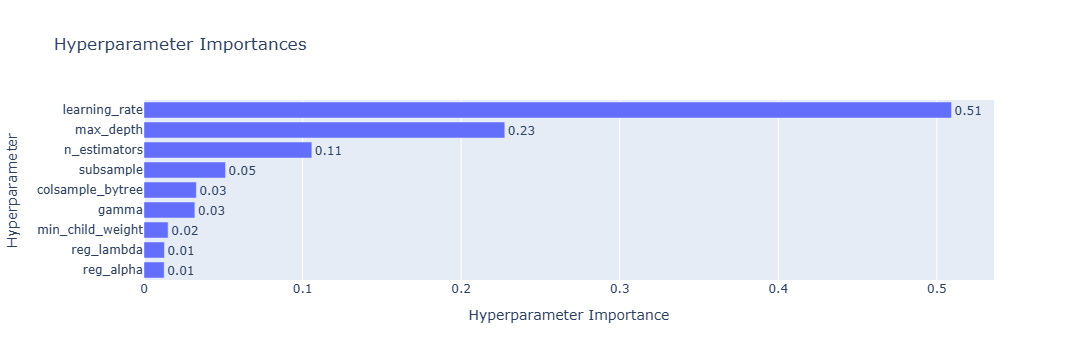

In [26]:
import optuna
print("\n" + "="*55)
print("  O2: Optuna Bayesian Optimization (100 trials)")
print("="*55)

def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1200),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 3.0),
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1,
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_full, y_full,
                             cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
study.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

best_params_optuna = study.best_params
print(f"\nBest MAE (Optuna): {study.best_value:.2f} mins")
print(f"Best params:\n{best_params_optuna}")

# Optuna importance plot
try:
    from optuna.visualization import plot_param_importances
    fig = plot_param_importances(study)
    fig.show()
except:
    pass

In [27]:
print("\n" + "="*55)
print("  O3: Bagging (BaggingRegressor over XGBoost)")
print("="*55)

# Use best params from Optuna as the base estimator
best_xgb = xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=1)

bagging_model = BaggingRegressor(
    estimator=best_xgb,
    n_estimators=10,          # 10 bags (XGBoost itself already bags internally
    max_samples=0.8,          # each bag sees 80% of data
    max_features=0.9,         # each bag sees 90% of features
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_mae, bagging_std = cv_mae(bagging_model, X_full, y_full)
print(f"Bagging MAE: {bagging_mae:.2f} ± {bagging_std:.2f} mins")

# Also try pure RF bagging for comparison
rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=best_params_optuna.get('max_depth', 6),
    min_samples_leaf=3,
    max_features=0.7,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_mae, rf_std = cv_mae(rf_tuned, X_full, y_full)
print(f"RF Bagging MAE:  {rf_mae:.2f} ± {rf_std:.2f} mins")


  O3: Bagging (BaggingRegressor over XGBoost)
Bagging MAE: 79.61 ± 5.43 mins
RF Bagging MAE:  80.68 ± 6.08 mins


In [28]:
# ── O4: Boosting variants ─────────────────────────────────────────────────────
print("\n" + "="*55)
print("  O4: Boosting variants")
print("="*55)

# 4a: Tuned XGBoost (Optuna best)
tuned_xgb = xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=-1)
xgb_mae, xgb_std = cv_mae(tuned_xgb, X_full, y_full)
print(f"Tuned XGBoost MAE:   {xgb_mae:.2f} ± {xgb_std:.2f} mins")

# 4b: LightGBM with Optuna-equivalent tuning
def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1200),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 3.0),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }
    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(model, X_full, y_full,
                             cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

study_lgb = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=60, show_progress_bar=True)

best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, n_jobs=-1)
lgb_mae, lgb_std = cv_mae(best_lgb, X_full, y_full)
print(f"Tuned LightGBM MAE:  {lgb_mae:.2f} ± {lgb_std:.2f} mins")
print(f"LGB best params: {study_lgb.best_params}")

# 4c: sklearn GradientBoosting (slower but different bias)
gb_model = GradientBoostingRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
gb_mae, gb_std = cv_mae(gb_model, X_full, y_full)
print(f"GradientBoosting MAE: {gb_mae:.2f} ± {gb_std:.2f} mins")


  O4: Boosting variants
Tuned XGBoost MAE:   77.45 ± 6.42 mins


[I 2026-06-20 23:35:09,139] A new study created in memory with name: no-name-8acedfaa-b031-4514-8cdd-8ada5e901793


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-06-20 23:38:44,934] Trial 0 finished with value: 89.59852970209491 and parameters: {'n_estimators': 574, 'max_depth': 10, 'learning_rate': 0.1001303991139125, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_samples': 12, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 2.665440364437338}. Best is trial 0 with value: 89.59852970209491.
[I 2026-06-20 23:40:30,884] Trial 1 finished with value: 80.3186559187432 and parameters: {'n_estimators': 801, 'max_depth': 8, 'learning_rate': 0.005439667429522981, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_samples': 14, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.9585112746335845}. Best is trial 1 with value: 80.3186559187432.
[I 2026-06-20 23:41:30,902] Trial 2 finished with value: 84.46007228352752 and parameters: {'n_estimators': 504, 'max_depth': 7, 'learning_rate': 0.029311198685320016, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 

In [29]:
print("\n" + "="*55)
print("  O5: Blending (weighted average) + Stacking")
print("="*55)

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import StackingRegressor


oof_xgb = cross_val_predict(
    xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=-1),
    X_full, y_full, cv=kf, n_jobs=1
)
oof_lgb = cross_val_predict(
    lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, n_jobs=-1),
    X_full, y_full, cv=kf, n_jobs=1
)
oof_rf = cross_val_predict(
    rf_tuned, X_full, y_full, cv=kf, n_jobs=-1
)

# Find optimal blend weights by grid search over OOF
best_blend_mae = 999
best_w = (0.34, 0.33, 0.33)
for w1 in np.arange(0.2, 0.7, 0.1):
    for w2 in np.arange(0.1, 0.6, 0.1):
        w3 = 1 - w1 - w2
        if w3 < 0.05: continue
        blend = w1 * oof_xgb + w2 * oof_lgb + w3 * oof_rf
        mae   = mean_absolute_error(y_full, blend)
        if mae < best_blend_mae:
            best_blend_mae = mae
            best_w = (w1, w2, w3)

print(f"\nBlend OOF MAE: {best_blend_mae:.2f} mins")
print(f"Best weights  — XGB:{best_w[0]:.1f}  LGB:{best_w[1]:.1f}  RF:{best_w[2]:.1f}")

stack_model = StackingRegressor(
    estimators=[
        ('xgb', xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=1)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, n_jobs=1)),
        ('rf',  rf_tuned),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
)
stack_mae, stack_std = cv_mae(stack_model, X_full, y_full)
print(f"\nStacking MAE:  {stack_mae:.2f} ± {stack_std:.2f} mins")

stack_lasso = StackingRegressor(
    estimators=[
        ('xgb', xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=1)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, n_jobs=1)),
        ('rf',  rf_tuned),
    ],
    final_estimator=Lasso(alpha=0.1),
    cv=5, n_jobs=-1
)
stack_lasso_mae, stack_lasso_std = cv_mae(stack_lasso, X_full, y_full)
print(f"Stacking+Lasso MAE: {stack_lasso_mae:.2f} ± {stack_lasso_std:.2f} mins")


  O5: Blending (weighted average) + Stacking

Blend OOF MAE: 77.92 mins
Best weights  — XGB:0.6  LGB:0.3  RF:0.1

Stacking MAE:  77.96 ± 6.48 mins
Stacking+Lasso MAE: 77.96 ± 6.48 mins


In [30]:
from sklearn.model_selection import cross_validate
import numpy as np

def cv_metrics(model, X, y, cv):
    scores = cross_validate(
        model,
        X, y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        return_train_score=False
    )

    mae = -scores["test_mae"].mean()
    rmse = -scores["test_rmse"].mean()
    r2 = scores["test_r2"].mean()

    mae_std = scores["test_mae"].std()
    rmse_std = scores["test_rmse"].std()
    r2_std = scores["test_r2"].std()

    return mae, rmse, r2, mae_std, rmse_std, r2_std

In [31]:
# 1) Tuned XGBoost
tuned_xgb = xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=-1)
xgb_mae, xgb_rmse, xgb_r2, xgb_mae_std, xgb_rmse_std, xgb_r2_std = cv_metrics(tuned_xgb, X_full, y_full, kf)

print(f"Tuned XGBoost  -> MAE: {xgb_mae:.2f} ± {xgb_mae_std:.2f}, "
      f"RMSE: {xgb_rmse:.2f} ± {xgb_rmse_std:.2f}, R²: {xgb_r2:.4f} ± {xgb_r2_std:.4f}")


# 2) Bagging over XGBoost
best_xgb = xgb.XGBRegressor(**best_params_optuna, verbosity=0, n_jobs=1)
bagging_model = BaggingRegressor(
    estimator=best_xgb,
    n_estimators=10,
    max_samples=0.8,
    max_features=0.9,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bag_mae, bag_rmse, bag_r2, bag_mae_std, bag_rmse_std, bag_r2_std = cv_metrics(bagging_model, X_full, y_full, kf)

print(f"Bagging XGB    -> MAE: {bag_mae:.2f} ± {bag_mae_std:.2f}, "
      f"RMSE: {bag_rmse:.2f} ± {bag_rmse_std:.2f}, R²: {bag_r2:.4f} ± {bag_r2_std:.4f}")


# 3) Random Forest
rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=best_params_optuna.get('max_depth', 6),
    min_samples_leaf=3,
    max_features=0.7,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_mae, rf_rmse, rf_r2, rf_mae_std, rf_rmse_std, rf_r2_std = cv_metrics(rf_tuned, X_full, y_full, kf)

print(f"RandomForest   -> MAE: {rf_mae:.2f} ± {rf_mae_std:.2f}, "
      f"RMSE: {rf_rmse:.2f} ± {rf_rmse_std:.2f}, R²: {rf_r2:.4f} ± {rf_r2_std:.4f}")


# 4) LightGBM
best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, n_jobs=-1)
lgb_mae, lgb_rmse, lgb_r2, lgb_mae_std, lgb_rmse_std, lgb_r2_std = cv_metrics(best_lgb, X_full, y_full, kf)

print(f"LightGBM       -> MAE: {lgb_mae:.2f} ± {lgb_mae_std:.2f}, "
      f"RMSE: {lgb_rmse:.2f} ± {lgb_rmse_std:.2f}, R²: {lgb_r2:.4f} ± {lgb_r2_std:.4f}")


# 5) Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)

gb_mae, gb_rmse, gb_r2, gb_mae_std, gb_rmse_std, gb_r2_std = cv_metrics(gb_model, X_full, y_full, kf)

print(f"GradBoost      -> MAE: {gb_mae:.2f} ± {gb_mae_std:.2f}, "
      f"RMSE: {gb_rmse:.2f} ± {gb_rmse_std:.2f}, R²: {gb_r2:.4f} ± {gb_r2_std:.4f}")

Tuned XGBoost  -> MAE: 77.45 ± 6.42, RMSE: 169.54 ± 14.67, R²: 0.3071 ± 0.0466
Bagging XGB    -> MAE: 79.61 ± 5.43, RMSE: 173.24 ± 12.83, R²: 0.2756 ± 0.0357
RandomForest   -> MAE: 80.68 ± 6.08, RMSE: 172.67 ± 14.41, R²: 0.2803 ± 0.0538
LightGBM       -> MAE: 79.50 ± 6.42, RMSE: 170.51 ± 13.64, R²: 0.2974 ± 0.0602
GradBoost      -> MAE: 82.81 ± 7.35, RMSE: 174.17 ± 13.54, R²: 0.2666 ± 0.0636
